In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [3]:
data = []

for page in range(1, 11):
    url = f"https://quotes.toscrape.com/page/{page}/"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    quotes = soup.find_all('div', class_='quote')

    for quote in quotes:
        text = quote.find('span', class_='text').get_text()
        author = quote.find('small', class_='author').get_text()
        tags = quote.find_all('a', class_='tag')
        tags = [tag.get_text() for tag in tags]

        data.append({
            'quote': text,
            'author': author,
            'tags': ', '.join(tags)
        })

    print(f"Page {page} done — {len(quotes)} quotes found")

print(f"\nTotal quotes scraped: {len(data)}")

Page 1 done — 10 quotes found
Page 2 done — 10 quotes found
Page 3 done — 10 quotes found
Page 4 done — 10 quotes found
Page 5 done — 10 quotes found
Page 6 done — 10 quotes found
Page 7 done — 10 quotes found
Page 8 done — 10 quotes found
Page 9 done — 10 quotes found
Page 10 done — 10 quotes found

Total quotes scraped: 100


In [4]:
df = pd.DataFrame(data)
df.head(10)

,quote,author,tags
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational"
5,“Try not to become a man of success. Rather be...,Albert Einstein,"adulthood, success, value"
6,“It is better to be hated for what you are tha...,André Gide,"life, love"
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison,"edison, failure, inspirational, paraphrased"
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt,misattributed-eleanor-roosevelt
9,"“A day without sunshine is like, you know, nig...",Steve Martin,"humor, obvious, simile"


In [5]:
df = pd.DataFrame(data)

df.to_csv('quotes.csv', index=False)

print(f"Saved! Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Saved! Total rows: 100
Columns: ['quote', 'author', 'tags']


In [6]:
print("Shape of data:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nAny missing values?")
print(df.isnull().sum())

Shape of data: (100, 3)

Column names: ['quote', 'author', 'tags']

Any missing values?
quote     0
author    0
tags      0
dtype: int64


We'll answer 4 interesting questions from our data:
1.Who are the most quoted authors?
2.What are the most popular tags?
3.How long are the quotes? (character count distribution)
4.Which author writes the longest quotes?

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('quotes.csv')

sns.set_theme(style='whitegrid')
print("Data loaded!", df.shape)
df.head()

Data loaded! (100, 3)


,quote,author,tags
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational"


C:\Users\Mrunali karmore\AppData\Local\Temp\ipykernel_3160\3515689975.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette='Blues_r')


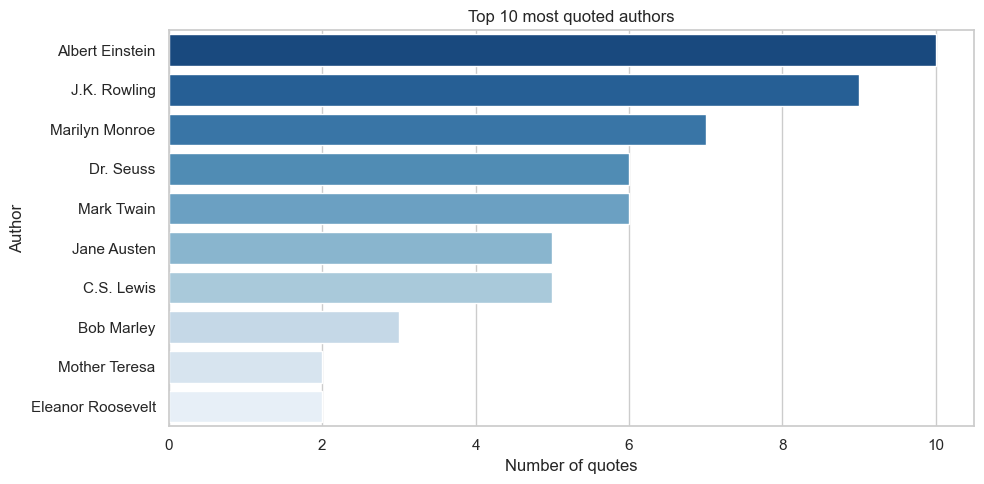

In [8]:
top_authors = df['author'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='Blues_r')
plt.title('Top 10 most quoted authors')
plt.xlabel('Number of quotes')
plt.ylabel('Author')
plt.tight_layout()
plt.show()

C:\Users\Mrunali karmore\AppData\Local\Temp\ipykernel_3160\3115119931.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tags.values, y=top_tags.index, palette='Greens_r')


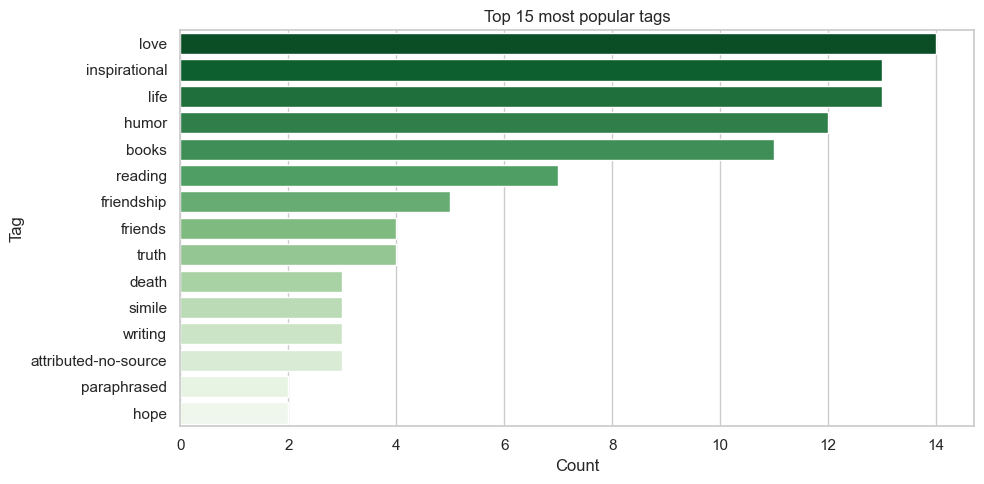

In [9]:
all_tags = df['tags'].dropna().str.split(', ').explode()

top_tags = all_tags.value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_tags.values, y=top_tags.index, palette='Greens_r')
plt.title('Top 15 most popular tags')
plt.xlabel('Count')
plt.ylabel('Tag')
plt.tight_layout()
plt.show()

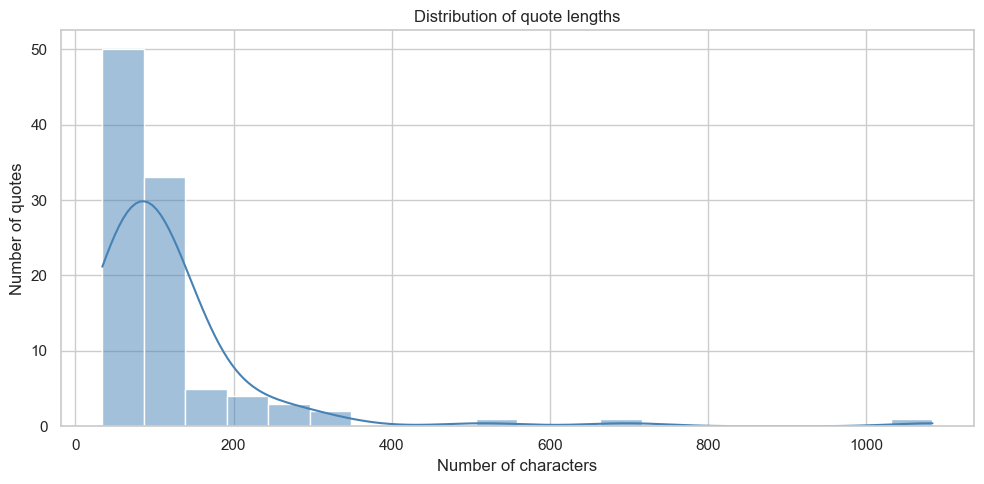

Shortest quote: 34 characters
Longest quote:  1084 characters
Average quote:  122 characters


In [10]:
df['quote_length'] = df['quote'].str.len()

plt.figure(figsize=(10, 5))
sns.histplot(df['quote_length'], bins=20, color='steelblue', kde=True)
plt.title('Distribution of quote lengths')
plt.xlabel('Number of characters')
plt.ylabel('Number of quotes')
plt.tight_layout()
plt.show()

print(f"Shortest quote: {df['quote_length'].min()} characters")
print(f"Longest quote:  {df['quote_length'].max()} characters")
print(f"Average quote:  {df['quote_length'].mean():.0f} characters")

C:\Users\Mrunali karmore\AppData\Local\Temp\ipykernel_3160\3379162293.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_length.values, y=avg_length.index, palette='Oranges_r')


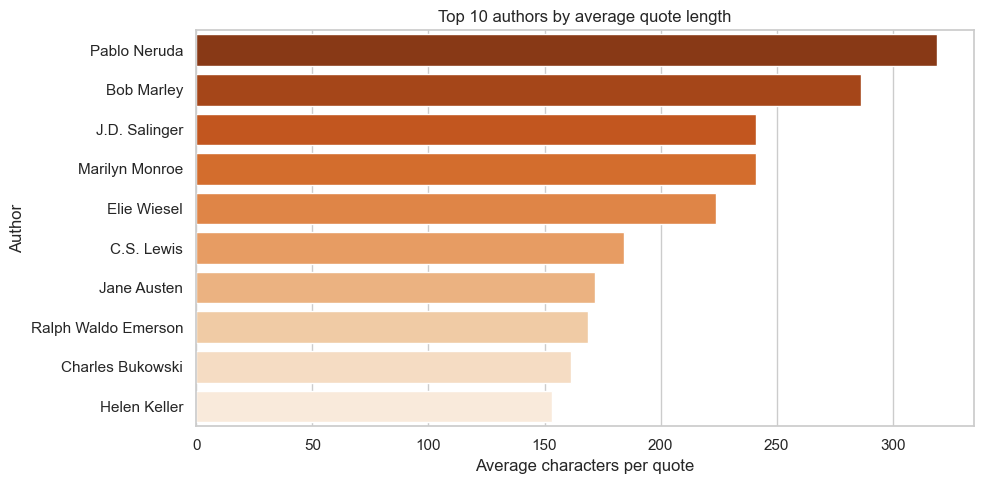

In [11]:
avg_length = df.groupby('author')['quote_length'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_length.values, y=avg_length.index, palette='Oranges_r')
plt.title('Top 10 authors by average quote length')
plt.xlabel('Average characters per quote')
plt.ylabel('Author')
plt.tight_layout()
plt.show()

In [12]:
# Step 1 - make an empty list to store author + tag pairs
author_tag_list = []

# Step 2 - loop through every row in the dataframe
for index, row in df.iterrows():
    author = row['author']
    
    # skip if tags is empty
    if pd.isna(row['tags']):
        continue
    
    # split the tags string into a list
    tags = row['tags'].split(', ')
    
    # for each tag, save author + tag as one entry
    for tag in tags:
        author_tag_list.append({
            'author': author,
            'tag': tag
        })

# Step 3 - convert to dataframe
author_tag_df = pd.DataFrame(author_tag_list)

# Step 4 - count each author + tag combination
author_tag_counts = author_tag_df.groupby(['author', 'tag']).size().reset_index(name='count')

# Step 5 - sort by count highest first
author_tag_counts = author_tag_counts.sort_values('count', ascending=False)

# Step 6 - for each author keep only their top tag
top_tag_per_author = author_tag_counts.groupby('author').first().reset_index()

# show the result
print(top_tag_per_author[['author', 'tag', 'count']].to_string(index=False))

                author                        tag  count
       Albert Einstein                       life      2
  Alexandre Dumas fils  misattributed-to-einstein      1
       Alfred Tennyson                 friendship      1
        Allen Saunders                       life      1
            André Gide                       life      1
            Bob Marley                 friendship      1
            C.S. Lewis                        age      1
      Charles Bukowski                    alcohol      1
     Charles M. Schulz                  chocolate      1
         Douglas Adams                       life      1
             Dr. Seuss                     comedy      1
         E.E. Cummings                    courage      1
     Eleanor Roosevelt                 attributed      1
           Elie Wiesel                   activism      1
      Ernest Hemingway                      books      1
   Friedrich Nietzsche           unhappy-marriage      1
      Garrison Keillor         

In [13]:
# group all quotes by author
grouped = df.groupby('author')['quote'].apply(list)

# print each author and their quotes
for author, quotes in grouped.items():
    print(f"\n{'='*60}")
    print(f"Author: {author}  ({len(quotes)} quotes)")
    print(f"{'='*60}")
    for i, quote in enumerate(quotes, 1):
        print(f"  {i}. {quote}")


Author: Albert Einstein  (10 quotes)
  1. “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
  2. “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
  3. “Try not to become a man of success. Rather become a man of value.”
  4. “If you can't explain it to a six year old, you don't understand it yourself.”
  5. “If you want your children to be intelligent, read them fairy tales. If you want them to be more intelligent, read them more fairy tales.”
  6. “Logic will get you from A to Z; imagination will get you everywhere.”
  7. “Any fool can know. The point is to understand.”
  8. “Life is like riding a bicycle. To keep your balance, you must keep moving.”
  9. “If I were not a physicist, I would probably be a musician. I often think in music. I live my daydreams in music. I see my life in terms of music.”
  10. “Anyone who has never made a mis

In [14]:
# change this name to any author you want
author_name = "Albert Einstein"

result = df[df['author'] == author_name]

print(f"Total quotes by {author_name}: {len(result)}\n")

for i, row in result.iterrows():
    print(f"Quote: {row['quote']}")
    print(f"Tags:  {row['tags']}")
    print("-" * 50)

Total quotes by Albert Einstein: 10

Quote: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
Tags:  change, deep-thoughts, thinking, world
--------------------------------------------------
Quote: “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
Tags:  inspirational, life, live, miracle, miracles
--------------------------------------------------
Quote: “Try not to become a man of success. Rather become a man of value.”
Tags:  adulthood, success, value
--------------------------------------------------
Quote: “If you can't explain it to a six year old, you don't understand it yourself.”
Tags:  simplicity, understand
--------------------------------------------------
Quote: “If you want your children to be intelligent, read them fairy tales. If you want them to be more intelligent, read them more fairy tales.”
Tags:  children, fairy-tales


In [15]:
summary = df.groupby('author').agg(
    total_quotes=('quote', 'count'),
    avg_length=('quote_length', 'mean'),
    tags_used=('tags', lambda x: ', '.join(x.dropna()))
).reset_index()

summary['avg_length'] = summary['avg_length'].round(0).astype(int)
summary = summary.sort_values('total_quotes', ascending=False)

print(summary[['author', 'total_quotes', 'avg_length']].to_string(index=False))

                author  total_quotes  avg_length
       Albert Einstein            10          94
          J.K. Rowling             9         118
        Marilyn Monroe             7         241
            Mark Twain             6          73
             Dr. Seuss             6         108
            C.S. Lewis             5         184
           Jane Austen             5         172
            Bob Marley             3         286
     Eleanor Roosevelt             2          63
      Charles Bukowski             2         162
       Suzanne Collins             2          76
    George R.R. Martin             2          91
         Mother Teresa             2          66
   Ralph Waldo Emerson             2         168
      Ernest Hemingway             2          60
  Alexandre Dumas fils             1          72
              Ayn Rand             1          74
       Alfred Tennyson             1          93
      Garrison Keillor             1         123
   Friedrich Nietzsc

# Web Scraping & Analysis Project
### Site: quotes.toscrape.com

---

## What I built
A complete web scraping pipeline — fetch, store and analyse 100 quotes from 10 pages.

---

## Questions answered

### Scraping
- How do you fetch a webpage using Python?
- How do you parse raw HTML and extract specific elements?
- How do you scrape multiple pages automatically?

### Storing
- How do you convert scraped data into a structured table?
- How do you save data to a CSV file?
- How do you check for missing values in a dataset?

### Analysis
- Which authors are quoted the most?
- What are the most popular tags across all quotes?
- How long are the quotes — what does the distribution look like?
- Which authors write the longest quotes on average?
- Which tag does each author use the most?
- What are all the quotes written by each author?

---

## Tools & Libraries
| Library | Purpose |
|---|---|
| `requests` | Fetch webpages |
| `BeautifulSoup` | Parse HTML and extract data |
| `pandas` | Store, clean and analyse data |
| `matplotlib` | Build charts |
| `seaborn` | Styled charts |
| `Jupyter Notebook` | Run code cell by cell |

---

## Project structure